<a href="https://colab.research.google.com/github/Delusional-bishop/Fortification-App/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload my_model.pt
!mkdir -p /content/my_model
!mv my_model.pt /content/my_model/my_model.pt

Saving my_model.pt to my_model.pt


In [ ]:
!pip install -q ultralytics opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.8 MB/s eta 0:00:00


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Video: 1920x1080, 25 FPS
Counting line at x=960
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


video 1/1 (frame 1/525) /content/output1.mp4: 384x640 (no detections), 62.9ms
Frame 1: 0 objects detected
video 1/1 (frame 2/525) /content/output1.mp4: 384x640 (no detections), 25.2ms
Frame 2: 0 objects detected
video 1/1 (frame 3/525) /content/output1.mp4: 384x640 (no detections), 25.2ms
Frame 3: 0 objects detected
video 1/1 (frame 4/525) /content/output1.mp4: 384x640 (no detections), 25.1ms
Frame 4: 0 objects detected

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

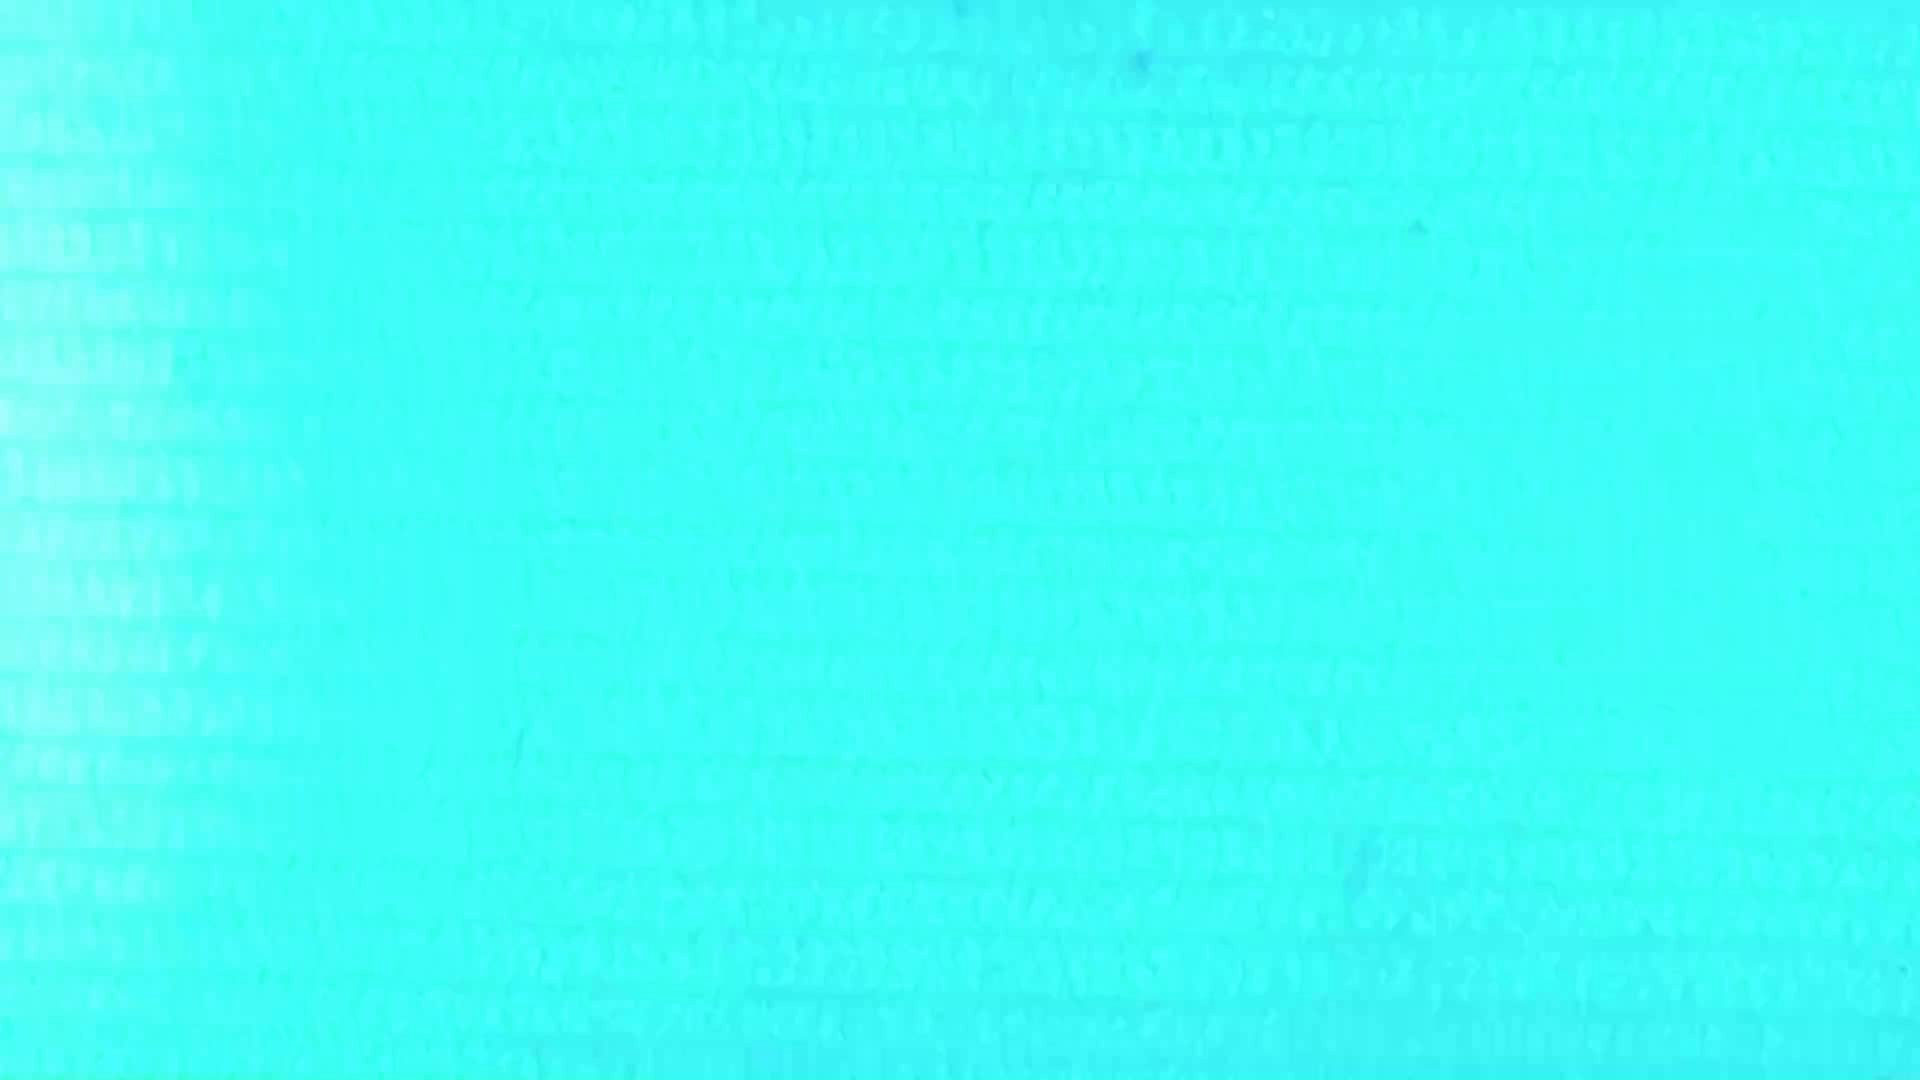

In [ ]:
# Install dependencies
# !pip install -q ultralytics opencv-python

# Import libraries
import cv2
import glob
import os
from ultralytics import YOLO
from collections import defaultdict
import numpy as np
from IPython.display import Image, display

# === LOAD TRAINED MODEL ===
latest_run = max(glob.glob('my_model/*.pt'), key=os.path.getctime, default=None)
if not latest_run:
    raise FileNotFoundError(f"Model file not found at '{latest_run}'")
model = YOLO(latest_run)

# === LOAD CLASS NAMES ===
def load_class_names(yaml_path="data.yaml"):
    import yaml
    with open(yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return data['names']

class_names = load_class_names()

# === CONFIGURATION ===
video_path = "/content/output1.mp4"
output_video_path = "/content/output_conveyor.mp4"
min_confidence = 0.3
tolerance = 20
frame_skip = 1

# === COUNT OBJECTS WITH TRACKING (VERTICAL LINE) ===
def count_objects_in_video(video_path, model, class_names, counting_line_x=None, output_path=None, tolerance=20, frame_skip=1):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video file: {video_path}")

    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    print(f"Video: {frame_width}x{frame_height}, {fps} FPS")

    if counting_line_x is None:
        counting_line_x = int(frame_width * 0.5)  # Middle of the frame
    print(f"Counting line at x={counting_line_x}")

    out = None
    if output_path:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    object_counts = defaultdict(int)
    total_count = 0
    counted_ids = set()
    frame_count = 0

    try:
        results = model.track(source=video_path, stream=True, persist=True, conf=min_confidence, iou=0.7, tracker="bytetrack.yaml")
    except Exception as e:
        print(f"Tracking failed: {e}. Falling back to prediction mode.")
        results = model.predict(source=video_path, stream=True, conf=min_confidence, iou=0.7)

    for frame_idx, result in enumerate(results):
        frame_count += 1
        if frame_count % frame_skip != 0:
            continue

        frame = result.orig_img
        print(f"Frame {frame_count}: {len(result.boxes)} objects detected")

        if not result.boxes:
            if out:
                out.write(frame)
            continue

        for box in result.boxes:
            if not hasattr(box, 'id') or box.id is None:
                continue  # Skip if no tracking ID

            object_id = int(box.id.item())
            class_id = int(box.cls)
            class_name = class_names[class_id]
            confidence = box.conf.item()
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2

            print(f"  Object: {class_name}, center_x={center_x}, confidence={confidence:.2f}, ID={object_id}")

            # Count if it crosses the vertical line
            if (center_x >= counting_line_x - tolerance and
                center_x <= counting_line_x + tolerance and
                object_id not in counted_ids):
                object_counts[class_name] += 1
                total_count += 1
                counted_ids.add(object_id)
                print(f"  Counted: {class_name}, ID={object_id}, total={total_count}")

            # Draw bounding box and label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{class_name} {confidence:.2f}", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            # Draw ID and center point
            cv2.circle(frame, (center_x, center_y), 4, (255, 255, 0), -1)
            cv2.putText(frame, f"ID:{object_id}", (center_x, center_y - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)

        # Draw vertical counting line and tolerance band
        cv2.line(frame, (counting_line_x, 0), (counting_line_x, frame_height), (0, 0, 255), 2)
        cv2.line(frame, (counting_line_x - tolerance, 0), (counting_line_x - tolerance, frame_height), (100, 100, 255), 1)
        cv2.line(frame, (counting_line_x + tolerance, 0), (counting_line_x + tolerance, frame_height), (100, 100, 255), 1)

        # Display counts on frame
        y_text = 30
        cv2.putText(frame, f"Total Objects: {total_count}", (10, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        for class_name, count in object_counts.items():
            y_text += 30
            cv2.putText(frame, f"{class_name}: {count}", (10, y_text),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        if out:
            out.write(frame)

    cap.release()
    if out:
        out.release()

    print(f"\nTotal Objects Detected: {total_count}")
    print("Counts by Class:")
    for class_name, count in object_counts.items():
        print(f"{class_name}: {count}")

    return object_counts, total_count

# === RUN COUNTING ===
object_counts, total_count = count_objects_in_video(
    video_path=video_path,
    model=model,
    class_names=class_names,
    counting_line_x=None,
    output_path=output_video_path,
    tolerance=tolerance,
    frame_skip=frame_skip
)

# === DOWNLOAD OUTPUT VIDEO ===
from google.colab import files
files.download(output_video_path)

# === DISPLAY SAMPLE FRAME ===
cap = cv2.VideoCapture(output_video_path)
ret, frame = cap.read()
if ret:
    cv2.imwrite('/content/sample_frame.jpg', frame)
    display(Image(filename='/content/sample_frame.jpg', height=400))
cap.release()
